In [1]:
import pandas as pd

import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs('../Data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

In [2]:
df_microbes = pd.read_csv(r"C:\Users\Usuario\Proyectos\Practica\microbes\Data\raw\microbes.csv")
display(df_microbes.head())

,Unnamed: 0,Solidity,Eccentricity,EquivDiameter,Extrema,FilledArea,Extent,Orientation,EulerNumber,BoundingBox1,...,ConvexHull4,MajorAxisLength,MinorAxisLength,Perimeter,ConvexArea,Centroid1,Centroid2,Area,raddi,microorganisms
0,0,10.70,15.8,5.43,3.75,0.785,8.14,2.15,22.3,2.97,...,2.97,1.34,1.61,0.683,0.195,3.63,12.10,1.310,7.99,Spirogyra
1,1,5.60,18.3,4.14,6.16,0.364,3.51,18.60,22.5,5.41,...,5.47,1.52,1.52,1.010,0.215,6.01,20.60,0.765,7.99,Spirogyra
2,2,8.32,19.8,4.63,6.66,0.415,5.85,21.00,22.4,5.96,...,5.96,1.63,1.38,1.110,0.182,6.55,11.50,0.953,7.99,Spirogyra
3,3,10.10,17.9,7.29,11.10,1.470,6.30,9.94,21.9,8.81,...,8.88,2.04,2.12,0.715,0.371,10.30,12.00,2.340,7.99,Spirogyra
4,4,6.27,20.2,20.10,10.70,14.700,3.97,2.58,11.9,10.20,...,10.20,7.78,6.21,6.800,4.440,14.00,9.55,17.600,7.99,Spirogyra


# Correlation Based Feature Selection

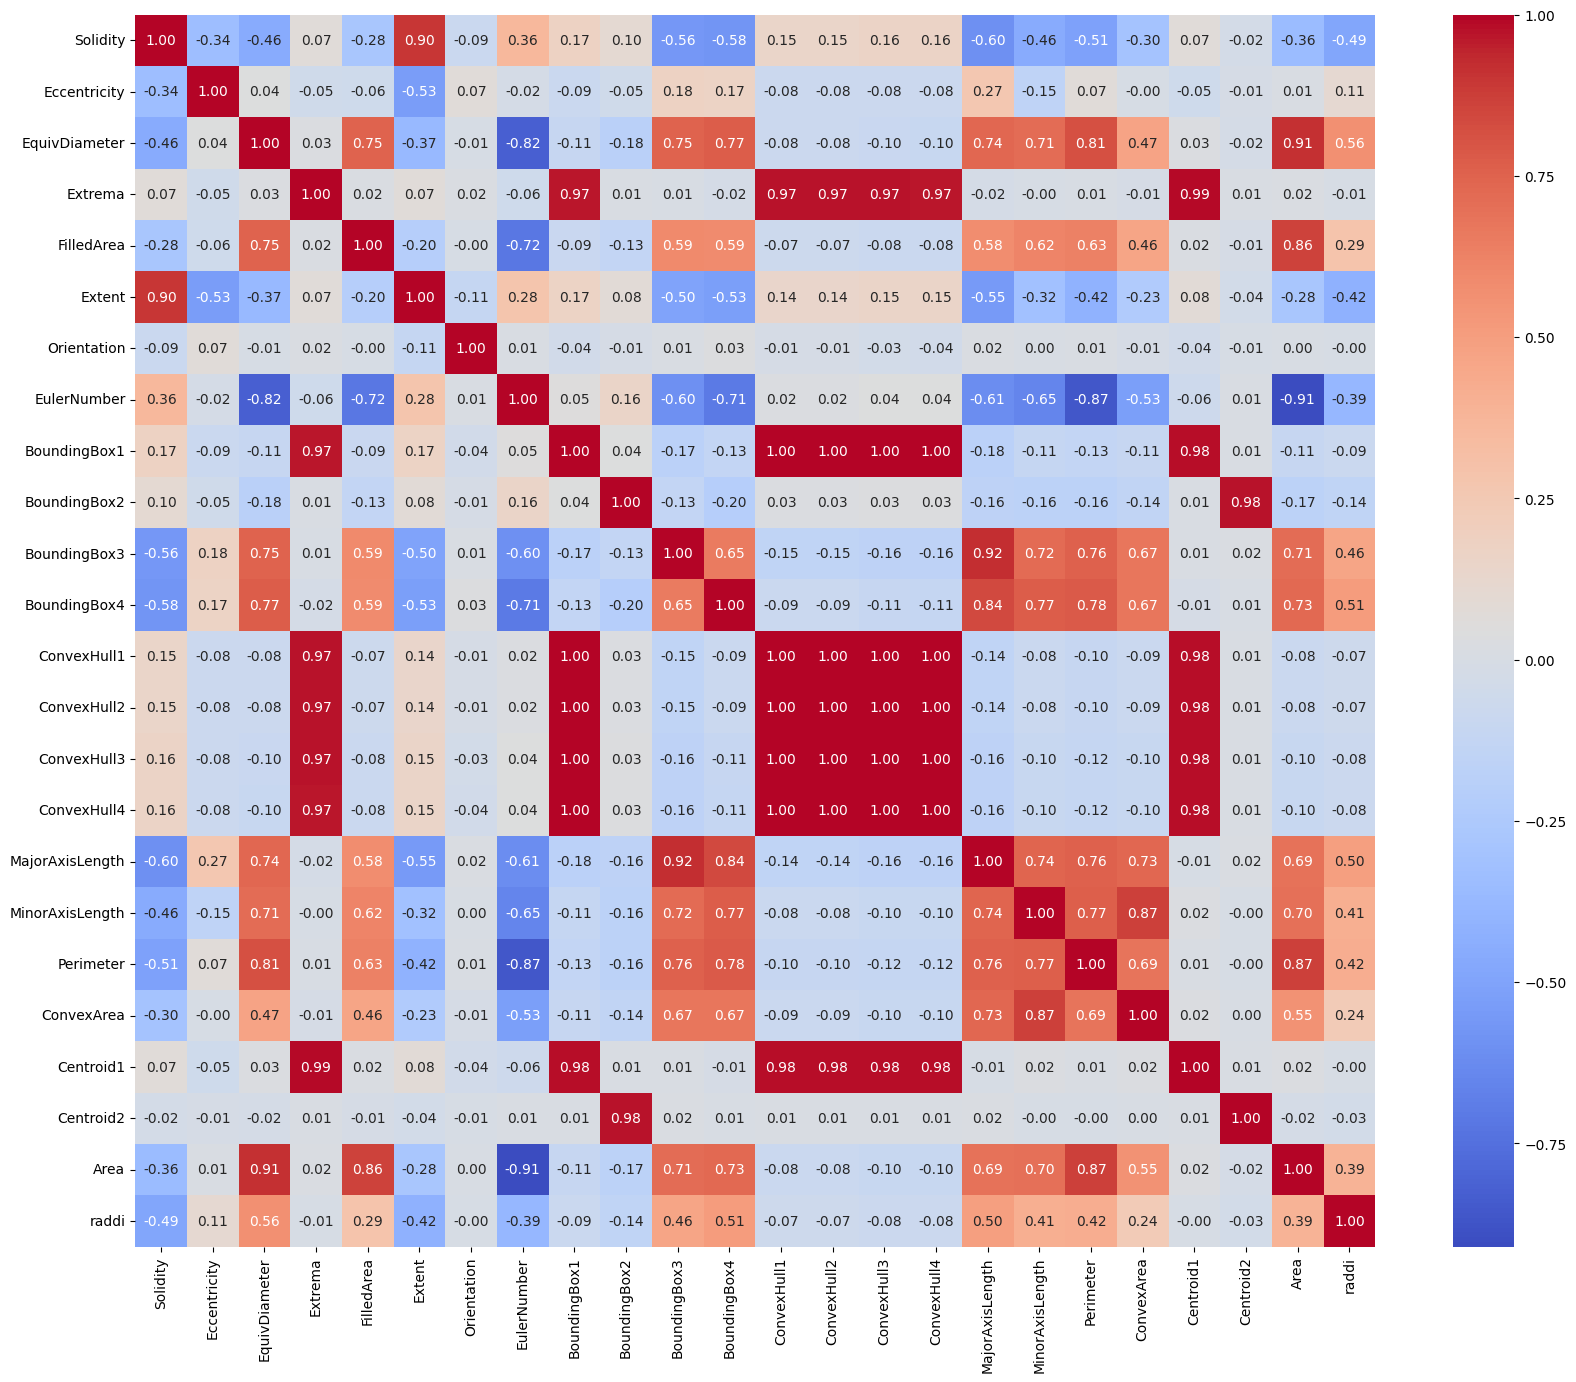

In [3]:
correlación = df_microbes.drop(columns= ['Unnamed: 0', 'microorganisms'])

plt.figure(figsize=(20, 16))
sns.heatmap(correlación.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [ ]:
subset = df_microbes[['ConvexHull4', 'ConvexHull3', 'ConvexHull2', 'ConvexHull1']]
print(subset.corr())


             ConvexHull4  ConvexHull3  ConvexHull2  ConvexHull1
ConvexHull4     1.000000     0.998903     0.995762     0.995762
ConvexHull3     0.998903     1.000000     0.997136     0.997136
ConvexHull2     0.995762     0.997136     1.000000     1.000000
ConvexHull1     0.995762     0.997136     1.000000     1.000000


Since there is a high correlation between all the ConvexHull features, I will delete ConvexHull 2,3 and 4 to reduce dimensionality and avoid redundancy in the training model. 

In [5]:
df_final = df_microbes.copy()

df_final.drop(columns= ['Unnamed: 0', 'ConvexHull2', 'ConvexHull3', 'ConvexHull4'], inplace= True)

# Data Split

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

X = df_final.drop(columns='microorganisms')
y = df_final['microorganisms']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

import json
with open('../data/processed/feature_names.json', 'w') as f:
    json.dump(list(X.columns), f)


np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy', y_test)